# Notebook 8: Capstone — Resisted Hinge and Three-Scenario Comparison

## Completing the Trilogy: Passive, Assisted, Resisted

In Notebooks 6 and 7 we saw the impedance controller track a pendulum trajectory with
a **passive hinge** (no external torque) and an **assisted hinge** (proportional torque
helping the controller). Now we reverse the hinge torque to **resist** the controller.

**This completes the three-scenario comparison:** how does the same impedance controller
perform when the environment is neutral, helpful, or hostile?

| Scenario | Hinge motor | Effect on tracking |
|----------|-------------|--------------------|
| Passive (NB 06) | Off | Baseline |
| Assisted (NB 07) | Proportional assist $+\alpha\,\tau_{imp}$ | Improved |
| Resisted (NB 08) | Proportional resist $-\alpha\,\tau_{imp}$ | Degraded |

The **payoff moment**: all three scenarios side by side in a single 2×3 figure.

## Setup (Self-Contained)

In [1]:
import os
import tempfile
import dms
import dms.mujoco
import mujoco
import numpy as np
import matplotlib.pyplot as plt
import mediapy as media
%matplotlib inline

print(f"MuJoCo version: {mujoco.__version__}")
print(f"NumPy version:  {np.__version__}")

MuJoCo version: 3.6.0
NumPy version:  2.4.3


## Load Model and Extract Named Indices

In [2]:
# Self-contained: load model and extract indices (same as NB 06, 07)
model_path = dms.get_asset_path('mujoco_models/tendon_block_hinge.xml')
model = mujoco.MjModel.from_xml_path(str(model_path))

hinge_qpos_idx  = model.joint("hinge").qposadr[0]
hinge_vel_idx   = model.joint("hinge").dofadr[0]
block_slide_idx = model.joint("block_slide").qposadr[0]
block_vel_idx   = model.joint("block_slide").dofadr[0]
block_ctrl_idx  = model.actuator("block_motor").id
hinge_ctrl_idx  = model.actuator("hinge_motor").id

tendon_id       = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_TENDON, "cable")
L_natural       = model.tendon_lengthspring[tendon_id, 1]
CABLE_STIFFNESS = model.tendon_stiffness[tendon_id]

print(f"Model loaded: nq={model.nq}, nu={model.nu}, ntendon={model.ntendon}")
print(f"L_natural={L_natural:.4f} m, stiffness={CABLE_STIFFNESS:.1f} N/m")

Model loaded: nq=2, nu=2, ntendon=1
L_natural=2.0000 m, stiffness=200.0 N/m


## Controller (Identical to NB 06, 07 — Same Gains, Same Structure)

In [3]:
# Same gains and controller as NB 06, 07 — only alpha_assist changes between scenarios
K        = 50.0    # Nm/rad
D        = 10.0    # Nm*s/rad
L_ROD    = 0.5     # m -- pendulum rod length

CORNER_X = 0.5
CORNER_Z = 1.5
PIVOT_X  = 0.0
PIVOT_Z  = 1.0
SEG1_AT_ZERO = 1.5

K_BLOCK  = 2000.0  # N/m
D_BLOCK  = 50.0    # N*s/m


def compute_r_eff(q):
    """Signed effective moment arm: Y-component of (r x f_hat)."""
    tip_x = PIVOT_X + L_ROD * np.cos(q)
    tip_z = PIVOT_Z - L_ROD * np.sin(q)
    r_x = tip_x - PIVOT_X
    r_z = tip_z - PIVOT_Z
    dx = CORNER_X - tip_x
    dz = CORNER_Z - tip_z
    d  = np.sqrt(dx**2 + dz**2)
    return r_z * (dx / d) - r_x * (dz / d)


def capstone_controller(model, data, q_des, dq_des, tau_hinge=0.0):
    """Two-level impedance controller (identical to NB 06, 07).

    tau_hinge=0.0 -> passive scenario (NB 06)
    tau_hinge>0.0 -> assisted scenario (NB 07)
    tau_hinge<0.0 -> resisted scenario (NB 08)
    """
    q  = data.qpos[hinge_qpos_idx].copy()
    dq = data.qvel[hinge_vel_idx].copy()

    tau_imp   = K * (q_des - q) + D * (dq_des - dq)
    tau_grav  = data.qfrc_bias[hinge_vel_idx]
    tau_total = tau_imp + tau_grav

    r_eff = compute_r_eff(q)
    T_desired = max(0.0, tau_total / r_eff)
    L_desired = T_desired / CABLE_STIFFNESS + L_natural

    tip_x = PIVOT_X + L_ROD * np.cos(q)
    tip_z = PIVOT_Z - L_ROD * np.sin(q)
    seg2  = np.sqrt((tip_x - CORNER_X)**2 + (tip_z - CORNER_Z)**2)

    seg1_desired = L_desired - seg2
    block_x_des  = np.clip(SEG1_AT_ZERO - seg1_desired, -1.0, 0.5)

    block_x  = data.qpos[block_slide_idx].copy()
    block_xd = data.qvel[block_vel_idx].copy()
    F_block  = K_BLOCK * (block_x_des - block_x) + D_BLOCK * (0.0 - block_xd)

    data.ctrl[block_ctrl_idx] = np.clip(F_block, -100.0, 100.0)
    data.ctrl[hinge_ctrl_idx] = tau_hinge


def get_cable_tension(data, tendon_idx=0):
    stretch = float(data.ten_length[tendon_idx]) - L_natural
    return CABLE_STIFFNESS * max(0.0, stretch)


print("Controller ready (same as NB 06, 07).")

Controller ready (same as NB 06, 07).


## Theory: Resisted Hinge

### Reversing the Assist: Proportional Resistance

In Notebook 7 the hinge applied a *helping* torque:

$$\tau_{hinge} = +\alpha \cdot \tau_{imp} \quad (\alpha > 0, \; \text{assisted})$$

Now we apply an *opposing* torque of the same magnitude:

$$\tau_{hinge} = -\alpha \cdot \tau_{imp} \quad (\alpha > 0, \; \text{resisted})$$

With $\tau_{ext} < 0$ opposing the direction the impedance controller tries to
move the pendulum, the **effective error increases**. The controller must generate
more tendon tension to overcome the resistance, and if $K$ and $D$ are not large
enough, tracking degrades.

### Why Tracking Degrades

In the passive scenario the cable carries 100% of the required torque. In the
resisted scenario the hinge motor continuously opposes the impedance controller:

$$\tau_{cable} = \tau_{imp} - \tau_{hinge} = \tau_{imp} + \alpha\,|\tau_{imp}| = (1+\alpha)\,\tau_{imp}$$

The cable must carry **more** than 100% of the impedance torque — it also
compensates for the resisting hinge torque. This increases the required cable
stretch, block displacement, and position lag.

This simulates an environment that **fights the controller** — like a stiff joint,
external friction, or an opposing load on the pendulum.

## Reusable Simulation Function

We define a helper that runs a single scenario and returns the recorded history.
The same function is called three times — for passive, assisted, and resisted —
keeping the comparison exactly fair.

In [4]:
def run_scenario(alpha_assist, sim_duration=5.0):
    """Run capstone sinusoidal tracking experiment for a given assist fraction.

    Args:
        alpha_assist: hinge assist fraction.
                      0.0 = passive (no hinge torque)
                      +0.4 = assisted (hinge helps controller)
                      -0.4 = resisted (hinge opposes controller)
        sim_duration: simulation time in seconds

    Returns:
        t_hist, q_hist, qd_hist, F_hist, rms_deg
    """
    A_des   = 0.3             # rad (~17 degrees)
    f_des   = 0.5             # Hz
    omega_d = 2 * np.pi * f_des
    dt      = model.opt.timestep
    n_steps = int(sim_duration / dt)

    # Each scenario gets a fresh MjData (no state leaks between runs)
    local_data = mujoco.MjData(model)
    mujoco.mj_forward(model, local_data)

    t_hist  = np.zeros(n_steps)
    q_hist  = np.zeros(n_steps)
    qd_hist = np.zeros(n_steps)
    F_hist  = np.zeros(n_steps)

    for i in range(n_steps):
        t      = local_data.time
        q_des  = A_des * np.sin(omega_d * t)
        dq_des = A_des * omega_d * np.cos(omega_d * t)

        # Record BEFORE stepping
        t_hist[i]  = t
        q_hist[i]  = local_data.qpos[hinge_qpos_idx].copy()
        qd_hist[i] = q_des
        F_hist[i]  = get_cable_tension(local_data)

        # Compute tau_imp for proportional hinge torque
        q  = local_data.qpos[hinge_qpos_idx].copy()
        dq = local_data.qvel[hinge_vel_idx].copy()
        tau_imp   = K * (q_des - q) + D * (dq_des - dq)
        tau_hinge = np.clip(alpha_assist * tau_imp, -10.0, 10.0)

        capstone_controller(model, local_data, q_des, dq_des, tau_hinge=tau_hinge)
        mujoco.mj_step(model, local_data)

    rms_deg = np.degrees(np.sqrt(np.mean((q_hist - qd_hist)**2)))
    return t_hist, q_hist, qd_hist, F_hist, rms_deg


print("Reusable run_scenario() helper ready.")
print("  alpha_assist = 0.0  -> passive")
print("  alpha_assist = +0.4 -> assisted")
print("  alpha_assist = -0.4 -> resisted")

Reusable run_scenario() helper ready.
  alpha_assist = 0.0  -> passive
  alpha_assist = +0.4 -> assisted
  alpha_assist = -0.4 -> resisted


## Experiment 1: Resisted Hinge Tracking

The hinge motor applies a **negative** proportional torque, opposing the
impedance controller at every timestep.

In [5]:
ALPHA_RESIST = -0.4   # negative: hinge opposes the controller

t_r, q_r, qd_r, F_r, rms_resisted = run_scenario(alpha_assist=ALPHA_RESIST)

print(f"Resisted scenario (alpha={ALPHA_RESIST}):")
print(f"  RMS tracking error: {rms_resisted:.2f} degrees")
print(f"  Lever range: [{np.degrees(q_r.min()):.1f}, {np.degrees(q_r.max()):.1f}] degrees")
print(f"  Max cable tension: {F_r.max():.2f} N")

Resisted scenario (alpha=-0.4):
  RMS tracking error: 2.17 degrees
  Lever range: [-16.4, 18.3] degrees
  Max cable tension: 14.98 N


## Experiment 2: Run All Three Scenarios

Re-run passive and assisted within this notebook (self-contained per the
notebook independence principle). All three scenarios use exactly the same
`run_scenario()` function — only the `alpha_assist` value changes.

In [6]:
ALPHA_PASSIVE  =  0.0
ALPHA_ASSIST   = +0.4
ALPHA_RESIST   = -0.4

print("Running all three scenarios...")
t_p, q_p, qd_p, F_p, rms_passive  = run_scenario(alpha_assist=ALPHA_PASSIVE)
print(f"  Passive  (alpha= 0.0): RMS = {rms_passive:.2f} deg")

t_a, q_a, qd_a, F_a, rms_assisted = run_scenario(alpha_assist=ALPHA_ASSIST)
print(f"  Assisted (alpha=+0.4): RMS = {rms_assisted:.2f} deg")

t_r, q_r, qd_r, F_r, rms_resisted = run_scenario(alpha_assist=ALPHA_RESIST)
print(f"  Resisted (alpha=-0.4): RMS = {rms_resisted:.2f} deg")

Running all three scenarios...
  Passive  (alpha= 0.0): RMS = 1.13 deg
  Assisted (alpha=+0.4): RMS = 0.78 deg
  Resisted (alpha=-0.4): RMS = 2.17 deg


## RMS Comparison Table

In [7]:
# Compute improvement and degradation
improvement_pct = (rms_passive - rms_assisted) / rms_passive * 100.0
degradation_pct = (rms_resisted - rms_passive) / rms_passive * 100.0

print("\nScenario    | alpha | RMS Error (deg) | vs Passive")
print("------------|-------|-----------------|-------------------")
print(f"Passive     |  0.0  |     {rms_passive:5.2f}       | baseline")
print(f"Assisted    | +0.4  |     {rms_assisted:5.2f}       | {improvement_pct:+.1f}% (better)")
print(f"Resisted    | -0.4  |     {rms_resisted:5.2f}       | {degradation_pct:+.1f}% (worse)")


Scenario    | alpha | RMS Error (deg) | vs Passive
------------|-------|-----------------|-------------------
Passive     |  0.0  |      1.13       | baseline
Assisted    | +0.4  |      0.78       | +30.9% (better)
Resisted    | -0.4  |      2.17       | +92.1% (worse)


## Validation

In [8]:
# Validate ordering: assisted < passive < resisted
assert rms_assisted < rms_passive, (
    f"Assisted RMS ({rms_assisted:.2f}°) must be less than passive ({rms_passive:.2f}°)"
)
assert rms_resisted > rms_passive, (
    f"Resisted RMS ({rms_resisted:.2f}°) must be greater than passive ({rms_passive:.2f}°)"
)

# Validate minimum thresholds (>20% in both directions)
assert improvement_pct > 20.0, (
    f"Assisted improvement {improvement_pct:.1f}% is below 20% threshold."
)
assert degradation_pct > 20.0, (
    f"Resisted degradation {degradation_pct:.1f}% is below 20% threshold."
)

print(f"PASS: Ordering confirmed — assisted ({rms_assisted:.2f}°) < passive ({rms_passive:.2f}°) < resisted ({rms_resisted:.2f}°)")
print(f"PASS: Assisted improvement {improvement_pct:.1f}% > 20% threshold")
print(f"PASS: Resisted degradation {degradation_pct:.1f}% > 20% threshold")

PASS: Ordering confirmed — assisted (0.78°) < passive (1.13°) < resisted (2.17°)
PASS: Assisted improvement 30.9% > 20% threshold
PASS: Resisted degradation 92.1% > 20% threshold


## Three-Scenario Comparison Figure

The culminating visualization: all three scenarios side by side.

- **Top row:** Lever angle tracking — desired (black dashed) vs actual (colored)
- **Bottom row:** Cable tension for each scenario
- **Columns:** Passive | Assisted | Resisted

The visually distinct trajectory curves tell the whole story at a glance:
- Assisted curves hug the desired trajectory (small gap)
- Passive curves show moderate lag
- Resisted curves show the largest departure from the desired path

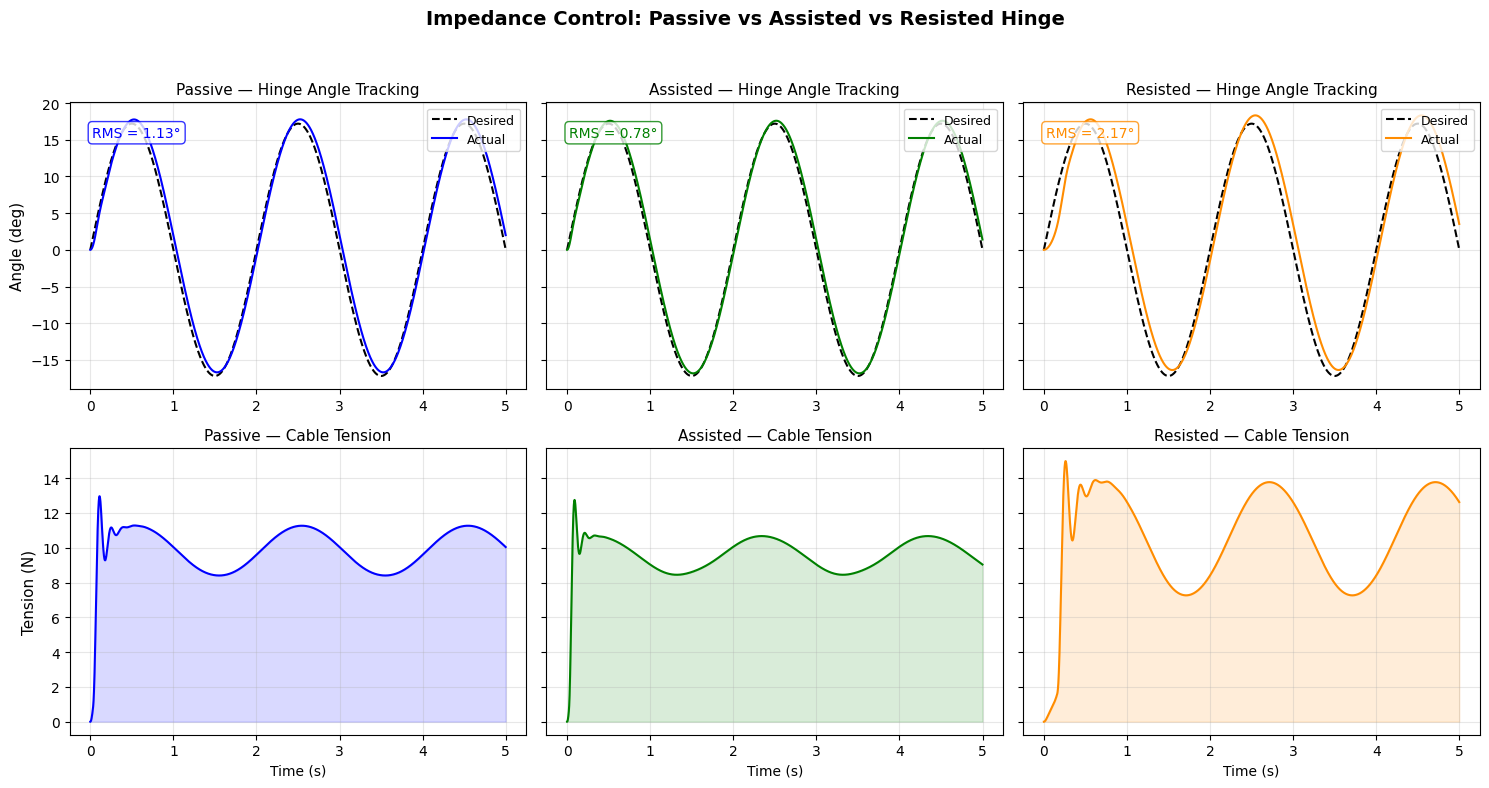

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey='row')

scenarios = [
    ("Passive",  t_p, q_p, qd_p, F_p, rms_passive,  'b',       ALPHA_PASSIVE),
    ("Assisted", t_a, q_a, qd_a, F_a, rms_assisted, 'g',       ALPHA_ASSIST),
    ("Resisted", t_r, q_r, qd_r, F_r, rms_resisted, 'darkorange', ALPHA_RESIST),
]

for col, (name, t, q, qd, F, rms, color, alpha) in enumerate(scenarios):
    ax_angle  = axes[0, col]
    ax_tension = axes[1, col]

    # --- Top row: angle tracking ---
    ax_angle.plot(t, np.degrees(qd), 'k--', lw=1.5, label='Desired')
    ax_angle.plot(t, np.degrees(q),  color=color, lw=1.5, label='Actual')
    ax_angle.set_title(f"{name} — Hinge Angle Tracking", fontsize=11)
    ax_angle.grid(True, alpha=0.3)
    ax_angle.legend(fontsize=9, loc='upper right')
    ax_angle.annotate(
        f'RMS = {rms:.2f}°',
        xy=(0.05, 0.88), xycoords='axes fraction',
        fontsize=10, color=color,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=color)
    )
    if col == 0:
        ax_angle.set_ylabel('Angle (deg)', fontsize=11)

    # --- Bottom row: cable tension ---
    ax_tension.plot(t, F, color=color, lw=1.5)
    ax_tension.fill_between(t, F, 0, alpha=0.15, color=color)
    ax_tension.set_title(f"{name} — Cable Tension", fontsize=11)
    ax_tension.set_xlabel('Time (s)', fontsize=10)
    ax_tension.grid(True, alpha=0.3)
    if col == 0:
        ax_tension.set_ylabel('Tension (N)', fontsize=11)

plt.suptitle(
    "Impedance Control: Passive vs Assisted vs Resisted Hinge",
    fontsize=14, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Optional: Interactive Passive Viewer

## Series Conclusion: Eight Notebooks, One Insight

### What the Comparison Teaches

The 2×3 figure above tells the complete story of impedance control and environmental
interaction. The **same controller gains** ($K=50$ Nm/rad, $D=10$ Nm·s/rad) produce
three measurably different outcomes depending on what the hinge motor does:

1. **Impedance control allows compliant interaction with the environment.**  
   The controller does not rigidly enforce the trajectory; it applies a restoring
   force proportional to the error. External forces change the effective stiffness
   and damping seen at the pendulum.

2. **The same controller gains produce different outcomes depending on environmental forces.**  
   Tuning gains for one environment does not guarantee performance in another.
   A robot picking up a heavy load (resisted) needs different gains than one
   moving freely through air (passive).

3. **Assisted environments improve tracking; resisted environments degrade it.**  
   When environment and controller work together, errors cancel. When they oppose
   each other, errors amplify. This is the physical meaning of impedance mismatch.

4. **Tendon-driven systems transmit force indirectly.**  
   The controller actuates the block, not the pendulum. Cable tension is a consequence
   of block position; hinge torque is a consequence of cable tension. Understanding
   this indirect chain — and compensating gravity within it — is what makes the
   controller work.

---

### Review

Over these 8 notebooks you have built impedance controllers from the simplest
1-DOF mass-spring-damper to a tendon-driven pulley-pendulum system.

| NB | System | New concept |
|----|--------|-------------|
| 1 | Mass-spring-damper (1-DOF) | Impedance law, gain-timestep stability |
| 2 | Pendulum | Gravity compensation, nonlinear geometry |
| 3 | 2-DOF planar arm | Multi-DOF coupling, joint-space impedance |
| 4 | Cartesian impedance | Task-space vs joint-space control |
| 5 | Tendon API intro | Cable springs, tension-only mechanics |
| 6 | Capstone passive | Two-level controller, cable-driven pendulum |
| 7 | Capstone assisted | Environmental assist, proportional sharing |
| 8 | Capstone resisted | Environmental resistance, degradation analysis |

The **core insight is always the same**:

$$\tau = K(\theta_d - \theta) + D(\dot{\theta}_d - \dot{\theta})$$

What changes is how the system geometry and environment mediate between your control
effort and the controlled variable. Gravity compensation, cable inverse kinematics,
and environmental torques all reshape the effective impedance — but the fundamental
law remains a spring and a damper tracking a desired trajectory.